In [ ]:
!pip install scikit-learn
!pip install tensorflow
!pip install pytorch-tabnet
!pip install category_encoders
!pip install optuna xgboost lightgbm scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import models
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Membaca file Excel
file_path = 'Insurance Data.xlsx'  # Ganti dengan path file kamu
df = pd.read_excel(file_path)

In [ ]:
# Menampilkan 5 baris pertama
print("Data Awal:")
df.head()

Data Awal:


,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Risk Profile,Previous Claims History,Credit Score,Driving Record,Life Events,Segmentation Group
0,CUST000001,43,Female,Married,Student,Medium,High School,Suburban,West Lisa,Inactive,...,Eco-Friendly,SMS,Morning,Mandarin,Low,4,470,Minor Violations,Retirement,C
1,CUST000002,22,Female,Married,Student,Medium,Master,Urban,Tyroneville,NaN,...,Eco-Friendly,Email,Evening,Indonesian,Low,3,577,Clean,Divorce,A
2,CUST000003,63,Male,Divorced,Retired,Low,High School,Urban,Jaredbury,Occasional,...,Fast Service,Phone,Morning,Spanish,Medium,3,390,Major Violations,Divorce,B
3,CUST000004,60,Female,Widowed,Business Owner,High,Bachelor,Suburban,Johnhaven,Active,...,Eco-Friendly,Phone,Evening,Spanish,Low,4,662,Minor Violations,Marriage,D
4,CUST000005,55,Male,Married,Teacher,Medium,PhD,Suburban,Davidton,Active,...,Comprehensive Coverage,SMS,Morning,French,Low,0,340,Major Violations,Childbirth,B


In [ ]:
# Informasi umum data
print("\nInformasi Data:")
print(df.info())


Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 30 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Customer ID                         150000 non-null  object        
 1   Age                                 150000 non-null  int64         
 2   Gender                              150000 non-null  object        
 3   Marital Status                      150000 non-null  object        
 4   Occupation                          150000 non-null  object        
 5   Income Level                        142500 non-null  object        
 6   Education Level                     142500 non-null  object        
 7   Geographic Information              150000 non-null  object        
 8   Location                            150000 non-null  object        
 9   Behavioral Data                     142500 non-null  object     

In [ ]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,Age,Policy Start Date,Policy Renewal Date,Interactions with Customer Service,Coverage Amount,Premium Amount,Deductible,Previous Claims History,Credit Score
count,150000.000000,150000,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,48.447300,2022-05-20 12:56:04.415999744,2024-11-18 10:57:48.671999744,9.470887,504721.832553,2545.394752,1051.883134,1.996993,573.902347
min,18.000000,2020-05-20 00:00:00,2024-05-20 00:00:00,0.000000,10001.000000,100.000000,100.010000,0.000000,300.000000
25%,33.000000,2021-05-19 00:00:00,2024-08-19 00:00:00,4.000000,257402.250000,1315.745000,575.762500,1.000000,437.000000
50%,48.000000,2022-05-21 00:00:00,2024-11-18 00:00:00,9.000000,504612.500000,2545.035000,1050.305000,2.000000,573.000000
75%,64.000000,2023-05-21 00:00:00,2025-02-18 00:00:00,14.000000,751412.000000,3772.140000,1529.880000,3.000000,711.000000
max,79.000000,2024-05-19 00:00:00,2025-05-20 00:00:00,19.000000,999996.000000,4999.960000,1999.990000,4.000000,849.000000
std,17.909818,NaN,NaN,5.770120,285601.378292,1416.633851,549.612108,1.412996,158.736283


In [ ]:
# Menghapus kolom 'Life Events' dari analisis missing value

# Hitung missing value hanya dari kolom lain
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Tampilkan hasil
print("Missing Values per Variable (tanpa 'Life Events'):")
print(missing_values.sort_values(ascending=False))

In [ ]:
# Menghapus kolom 'Life Events' dari analisis missing value
df_excluded = df.drop(columns=['Life Events'])

# Hitung missing value hanya dari kolom lain
missing_values = df_excluded.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Tampilkan hasil
print("Missing Values per Variable (tanpa 'Life Events'):")
print(missing_values.sort_values(ascending=False))

Missing Values per Variable (tanpa 'Life Events'):
Income Level       7500
Education Level    7500
Behavioral Data    7500
Claim History      7500
Risk Profile       7500
dtype: int64


In [ ]:
# df.drop(columns=['Location'], inplace=True)

In [ ]:
# Menghapus kolom 'Life Events' dari analisis missing value
df_excluded = df.drop(columns=['Life Events', 'Risk Profile'])

# Hitung missing value hanya dari kolom lain
missing_values = df_excluded.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Tampilkan hasil
print("Missing Values per Variable (tanpa 'Life Events'):")
print(missing_values.sort_values(ascending=False))

Missing Values per Variable (tanpa 'Life Events'):
Income Level       7500
Education Level    7500
Behavioral Data    7500
Claim History      7500
dtype: int64


In [ ]:
# Kolom yang akan diimputasi
cols_to_impute = ['Income Level', 'Education Level', 'Behavioral Data', 'Claim History']

# Ambil subset kolom untuk diimputasi
df_impute = df[cols_to_impute].copy()

# Simpan encoder untuk bisa di-decode kembali nanti
encoders = {}

# Lakukan encoding untuk data kategorikal
for col in cols_to_impute:
    le = LabelEncoder()
    df_impute[col] = df_impute[col].astype(str)  # Pastikan string
    df_impute[col] = le.fit_transform(df_impute[col])
    encoders[col] = le

# Gunakan SimpleImputer dengan strategi 'most_frequent' (paling umum)
imputer = SimpleImputer(strategy='most_frequent')
df_imputed_values = imputer.fit_transform(df_impute)

# Kembalikan ke DataFrame
df_imputed = pd.DataFrame(df_imputed_values, columns=cols_to_impute)

# Dekode hasilnya ke label string semula
for col in cols_to_impute:
    le = encoders[col]
    df_imputed[col] = df_imputed[col].round().astype(int)
    df_imputed[col] = le.inverse_transform(df_imputed[col])

# Timpa data asli
for col in cols_to_impute:
    df[col] = df_imputed[col]

In [ ]:
# # Load ulang data jika perlu (pastikan 'Risk Profile' masih ada missing)
# df = pd.read_excel('Insurance Data.xlsx', keep_default_na=False)

# Identifikasi nilai 'None' sebagai string, bukan NaN
df['Risk Profile'] = df['Risk Profile'].replace('None', 'None')  # pastikan tetap string
df['Risk Profile'] = df['Risk Profile'].replace('', pd.NA)       # jika kosong string

# Tandai missing value (jika 'None' bukan dianggap NaN, bisa pakai == 'None')
train_data = df[df['Risk Profile'].notna()].copy()
test_data = df[df['Risk Profile'].isna()].copy()

# Output jumlah data
print(f"Jumlah data latih (tidak missing): {len(train_data)}")
print(f"Jumlah data uji (missing): {len(test_data)}")

Jumlah data latih (tidak missing): 142500
Jumlah data uji (missing): 7500


In [ ]:
# Tampilkan beberapa baris sebagai contoh
print("\nContoh data train:")
train_data.head(30)


Contoh data train:


,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Risk Profile,Previous Claims History,Credit Score,Driving Record,Life Events,Segmentation Group
0,CUST000001,43,Female,Married,Student,Medium,High School,Suburban,West Lisa,Inactive,...,Eco-Friendly,SMS,Morning,Mandarin,Low,4,470,Minor Violations,Retirement,C
1,CUST000002,22,Female,Married,Student,Medium,Master,Urban,Tyroneville,nan,...,Eco-Friendly,Email,Evening,Indonesian,Low,3,577,Clean,Divorce,A
2,CUST000003,63,Male,Divorced,Retired,Low,High School,Urban,Jaredbury,Occasional,...,Fast Service,Phone,Morning,Spanish,Medium,3,390,Major Violations,Divorce,B
3,CUST000004,60,Female,Widowed,Business Owner,High,Bachelor,Suburban,Johnhaven,Active,...,Eco-Friendly,Phone,Evening,Spanish,Low,4,662,Minor Violations,Marriage,D
4,CUST000005,55,Male,Married,Teacher,Medium,PhD,Suburban,Davidton,Active,...,Comprehensive Coverage,SMS,Morning,French,Low,0,340,Major Violations,Childbirth,B
5,CUST000006,22,Male,Widowed,Engineer,Medium,Master,Suburban,Port Shirleymouth,Inactive,...,Eco-Friendly,App Notification,Evening,French,Medium,4,668,Major Violations,Childbirth,E
6,CUST000007,54,Male,Single,Unemployed,Medium,PhD,Suburban,West John,Occasional,...,Fast Service,Email,Evening,Mandarin,Medium,3,335,Clean,Job Change,C
7,CUST000008,42,Female,Single,Lawyer,High,High School,Urban,Austinborough,New,...,Fast Service,Email,Afternoon,Mandarin,Low,3,430,Minor Violations,Retirement,B
8,CUST000009,61,Male,Widowed,Unemployed,Medium,High School,Suburban,Edwardmouth,Inactive,...,Fast Service,Phone,Morning,English,Medium,1,672,Major Violations,Divorce,A
9,CUST000010,68,Male,Married,Engineer,Low,High School,Rural,Lake Robert,Active,...,Low Cost,Email,Afternoon,Spanish,Medium,4,415,Clean,Childbirth,B


In [ ]:
print("\nContoh data test:")
test_data.head(30)


Contoh data test:


,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Risk Profile,Previous Claims History,Credit Score,Driving Record,Life Events,Segmentation Group
20,CUST000021,61,Male,Married,Student,Low,High School,Urban,South Lisa,New,...,Comprehensive Coverage,SMS,Morning,French,NaN,3,758,Clean,Divorce,C
34,CUST000035,24,Male,Divorced,Engineer,Very High,High School,Rural,South Edwinville,Active,...,Eco-Friendly,Phone,Morning,Spanish,NaN,3,529,Clean,Job Change,D
62,CUST000063,77,Female,Married,Engineer,High,PhD,Suburban,East Jadeborough,Occasional,...,Fast Service,App Notification,Morning,English,NaN,2,793,Minor Violations,Job Change,D
81,CUST000082,74,Male,Widowed,Student,Medium,PhD,Urban,Burnschester,New,...,Comprehensive Coverage,Phone,Afternoon,Indonesian,NaN,0,423,Minor Violations,Childbirth,E
87,CUST000088,70,Male,Single,Teacher,Medium,Master,Rural,North Valerie,Active,...,Eco-Friendly,SMS,Evening,Indonesian,NaN,1,777,Minor Violations,Retirement,B
93,CUST000094,19,Female,Widowed,Engineer,Medium,Master,Urban,Hensonbury,Occasional,...,Low Cost,Email,Evening,English,NaN,2,340,Major Violations,NaN,C
113,CUST000114,46,Male,Single,Doctor,High,Bachelor,Urban,Williamsburgh,Inactive,...,Low Cost,Phone,Afternoon,Mandarin,NaN,1,550,Major Violations,Job Change,C
118,CUST000119,64,Male,Single,Student,Very High,Master,Urban,Lake Sylviaton,Occasional,...,Low Cost,Phone,Afternoon,Indonesian,NaN,2,757,Clean,Childbirth,E
120,CUST000121,76,Female,Widowed,Business Owner,Medium,PhD,Urban,Port Jennifer,Active,...,Comprehensive Coverage,App Notification,Afternoon,Indonesian,NaN,2,541,Clean,Job Change,C
132,CUST000133,32,Female,Widowed,Doctor,Medium,Master,Rural,Chapmanchester,Inactive,...,Eco-Friendly,Phone,Afternoon,Mandarin,NaN,1,608,Clean,Divorce,D


<ipython-input-14-493e815cedd2>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='Risk Profile', y=feature, palette='Set2')


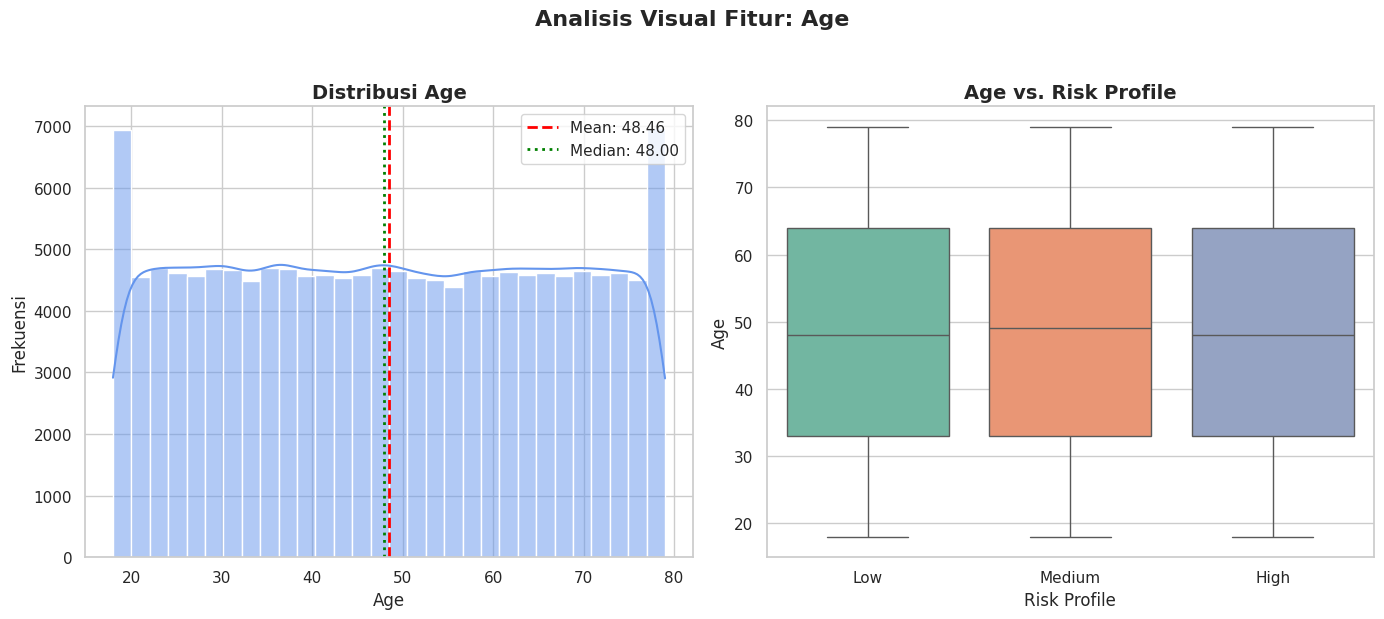

<ipython-input-14-493e815cedd2>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='Risk Profile', y=feature, palette='Set2')


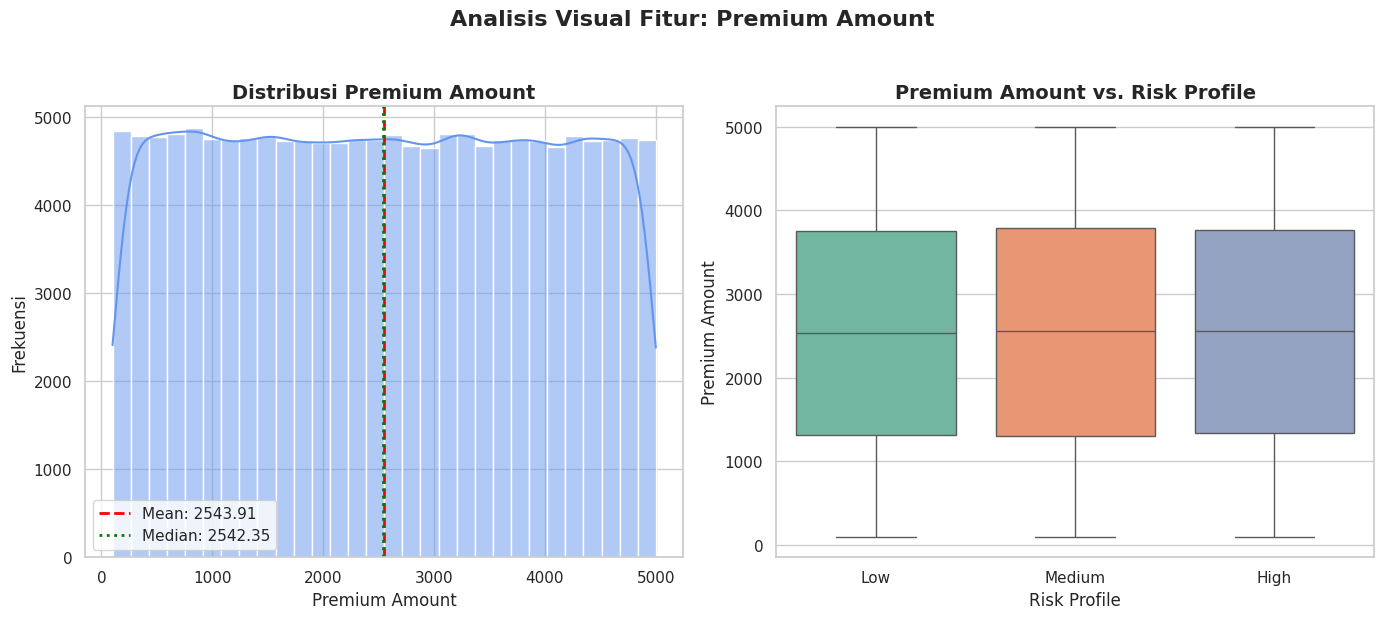

<ipython-input-14-493e815cedd2>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='Risk Profile', y=feature, palette='Set2')


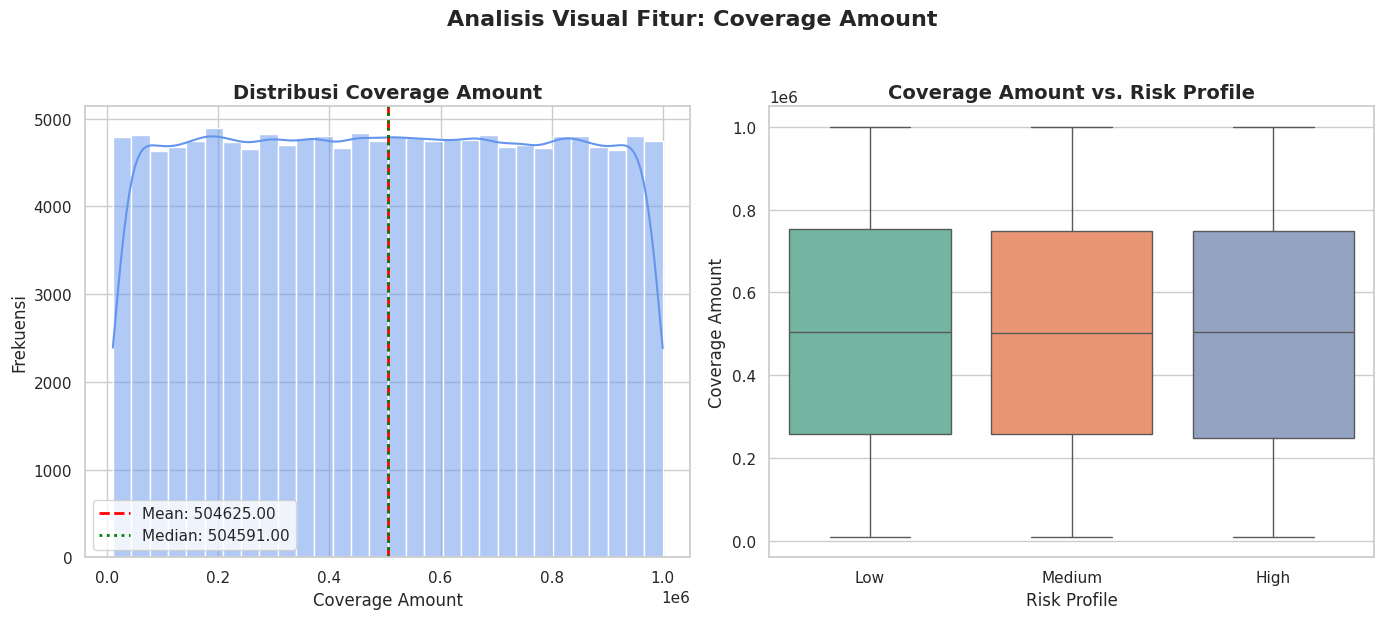

<ipython-input-14-493e815cedd2>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='Risk Profile', y=feature, palette='Set2')


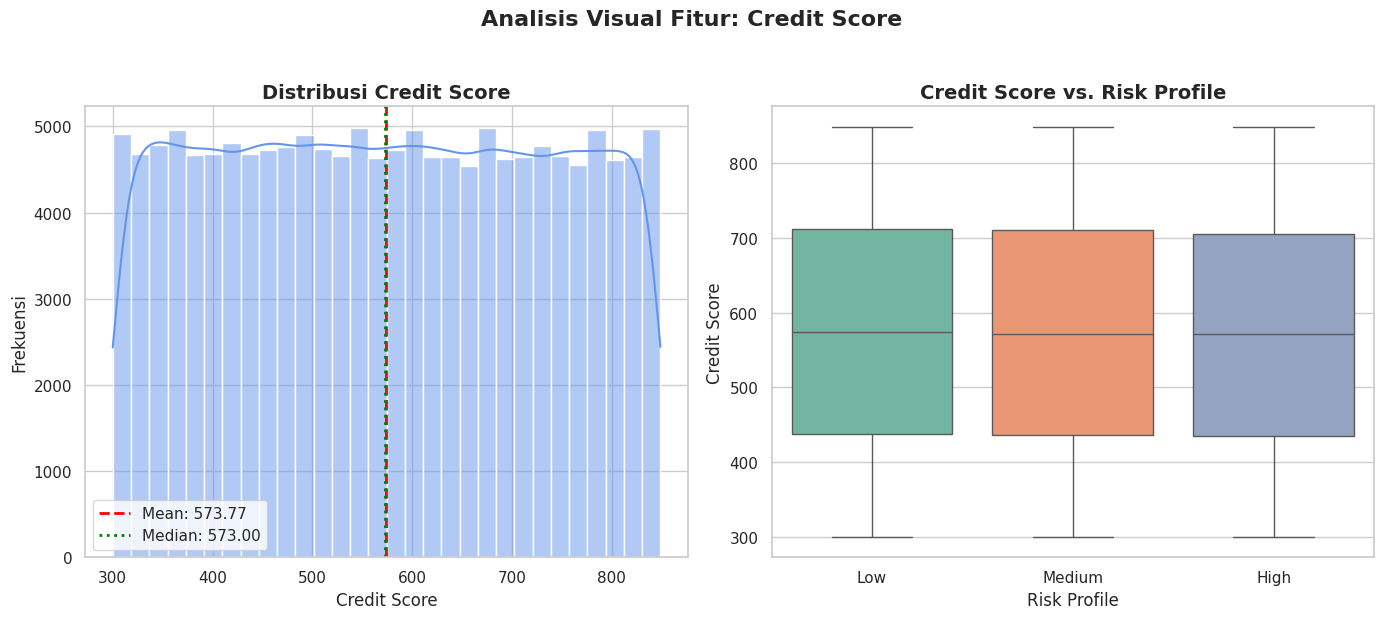

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Gunakan gaya seaborn yang bersih
sns.set(style='whitegrid')

if train_data is not None:
    numerical_features = ['Age', 'Premium Amount', 'Coverage Amount', 'Credit Score']

    for feature in numerical_features:
        if feature in train_data.columns:
            plt.figure(figsize=(14, 6))

            # Histogram + KDE
            plt.subplot(1, 2, 1)
            sns.histplot(train_data[feature], kde=True, bins=30, color='cornflowerblue', edgecolor='white')
            mean_val = train_data[feature].mean()
            median_val = train_data[feature].median()
            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            plt.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Median: {median_val:.2f}')
            plt.title(f'Distribusi {feature}', fontsize=14, fontweight='bold')
            plt.xlabel(feature, fontsize=12)
            plt.ylabel('Frekuensi', fontsize=12)
            plt.legend()

            # Boxplot terhadap Risk Profile
            plt.subplot(1, 2, 2)
            sns.boxplot(data=train_data, x='Risk Profile', y=feature, palette='Set2')
            plt.title(f'{feature} vs. Risk Profile', fontsize=14, fontweight='bold')
            plt.xlabel('Risk Profile', fontsize=12)
            plt.ylabel(feature, fontsize=12)

            # Judul keseluruhan
            plt.suptitle(f'Analisis Visual Fitur: {feature}', fontsize=16, fontweight='bold', y=1.03)
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️  Kolom '{feature}' tidak ditemukan di train_data.")
else:
    print("⚠️  DataFrame train_data tidak tersedia.")


<ipython-input-15-2fdef8674ad5>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perc.values, y=perc.index, palette='crest')


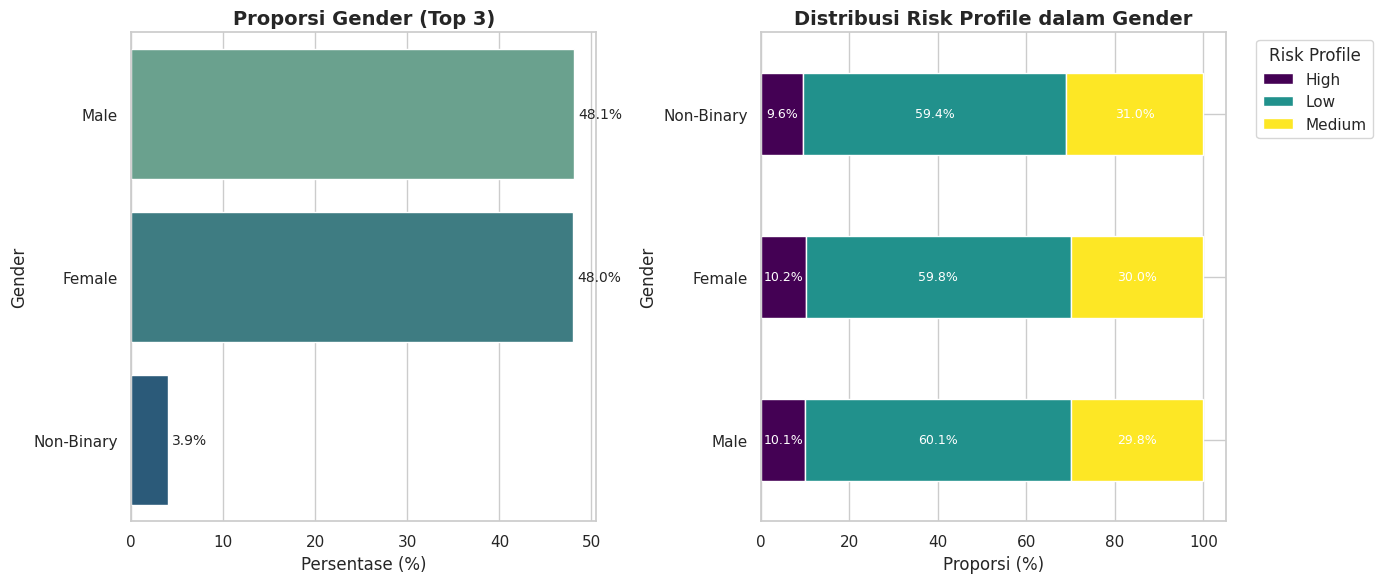

<ipython-input-15-2fdef8674ad5>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perc.values, y=perc.index, palette='crest')


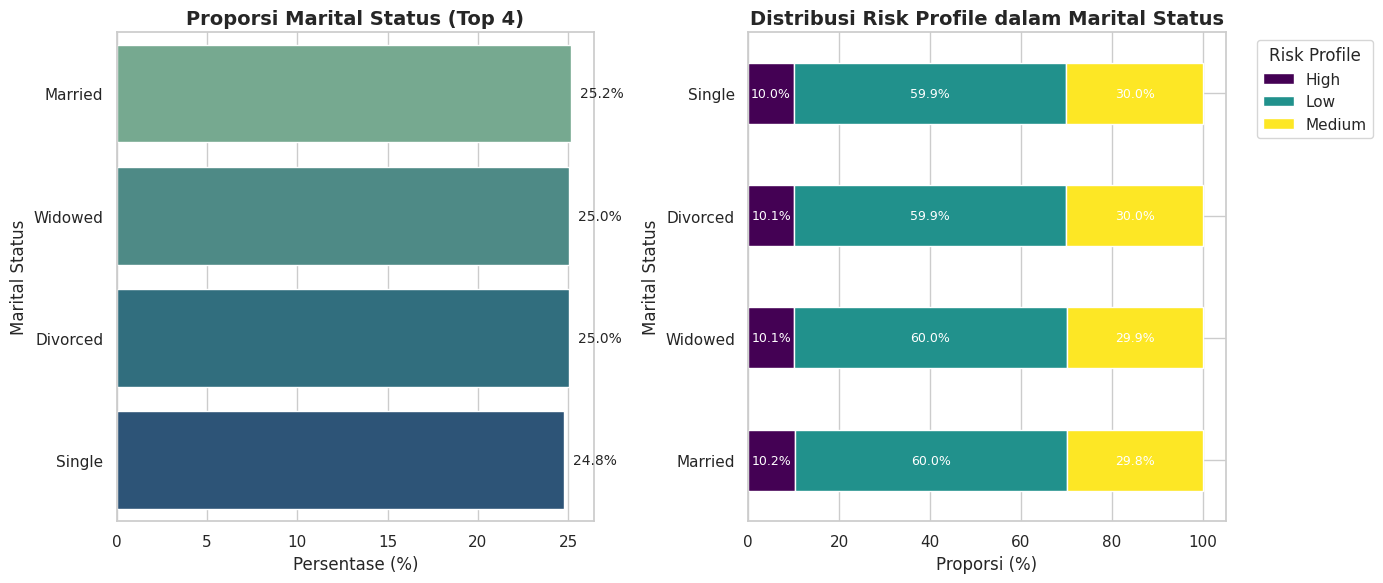

<ipython-input-15-2fdef8674ad5>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perc.values, y=perc.index, palette='crest')


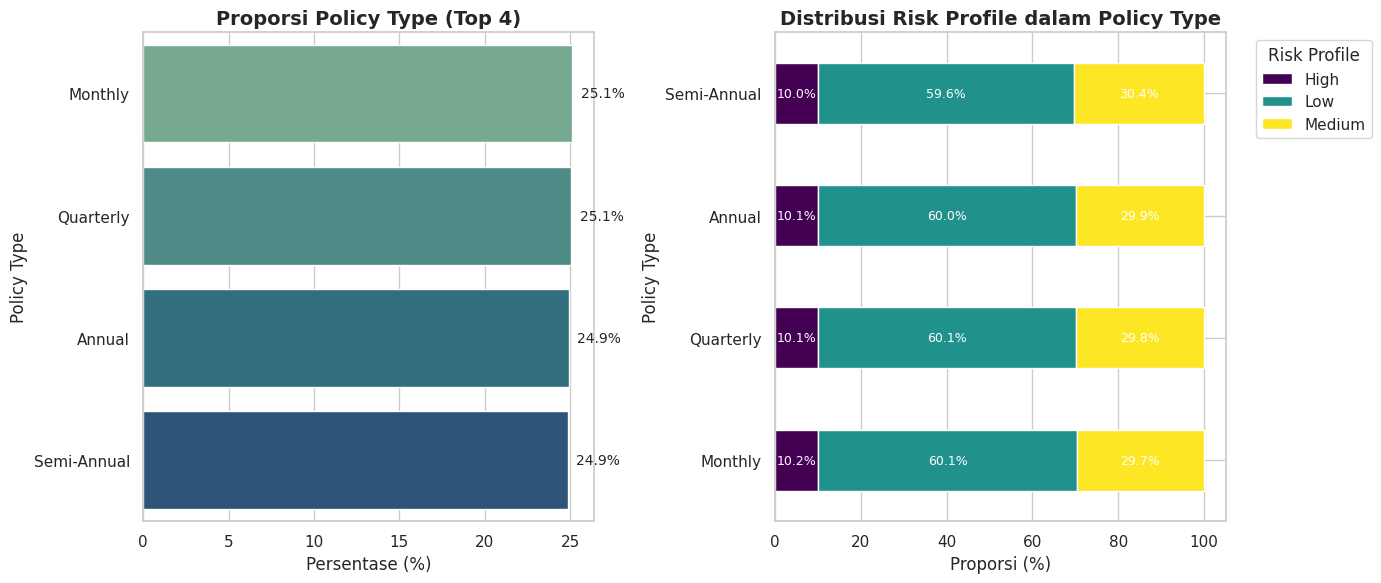

<ipython-input-15-2fdef8674ad5>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perc.values, y=perc.index, palette='crest')


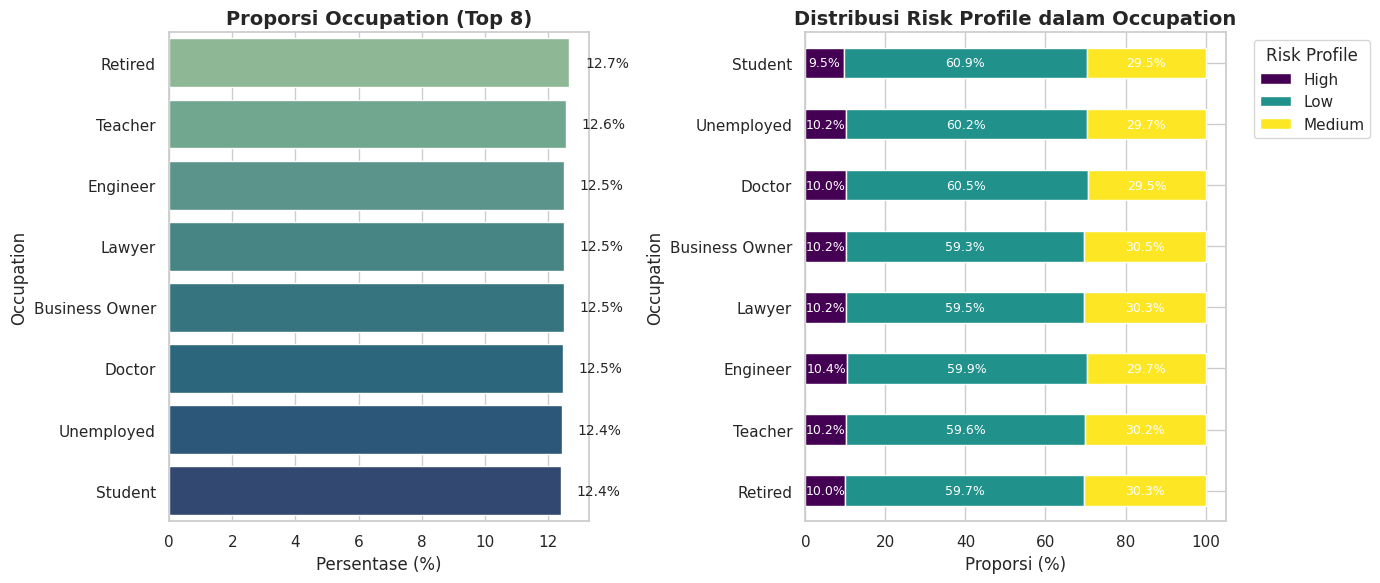

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style='whitegrid')

if train_data is not None:
    categorical_features = ['Gender', 'Marital Status', 'Policy Type', 'Occupation']

    for feature in categorical_features:
        if feature in train_data.columns:
            plt.figure(figsize=(14, 6))

            # Hitung distribusi kategori
            category_counts = train_data[feature].value_counts()
            top_n = category_counts.nlargest(10).index if category_counts.shape[0] > 10 else category_counts.index
            df_plot = train_data[train_data[feature].isin(top_n)]

            # Plot 1: Persentase kategori
            plt.subplot(1, 2, 1)
            perc = df_plot[feature].value_counts(normalize=True).loc[top_n] * 100
            sns.barplot(x=perc.values, y=perc.index, palette='crest')
            for i, v in enumerate(perc.values):
                plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
            plt.title(f'Proporsi {feature} (Top {len(top_n)})', fontsize=14, fontweight='bold')
            plt.xlabel('Persentase (%)')
            plt.ylabel(feature)

            # Plot 2: Stacked barplot per Risk Profile
            plt.subplot(1, 2, 2)
            ct = pd.crosstab(df_plot[feature], df_plot['Risk Profile'], normalize='index') * 100
            ct = ct.loc[top_n]
            ax = ct.plot(kind='barh', stacked=True, colormap='viridis', ax=plt.gca(), edgecolor='white')
            plt.title(f'Distribusi Risk Profile dalam {feature}', fontsize=14, fontweight='bold')
            plt.xlabel('Proporsi (%)')
            plt.ylabel(feature)
            plt.legend(title='Risk Profile', bbox_to_anchor=(1.05, 1), loc='upper left')

            # Tambahkan label angka pada stacked bar
            for i, (index, row) in enumerate(ct.iterrows()):
                cumulative = 0
                for j, value in enumerate(row):
                    if value > 5:  # tampilkan hanya jika nilai signifikan
                        ax.text(cumulative + value / 2, i, f'{value:.1f}%', va='center', ha='center', color='white', fontsize=9)
                    cumulative += value

            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️ Kolom '{feature}' tidak ditemukan.")
else:
    print("⚠️ DataFrame train_data tidak tersedia.")


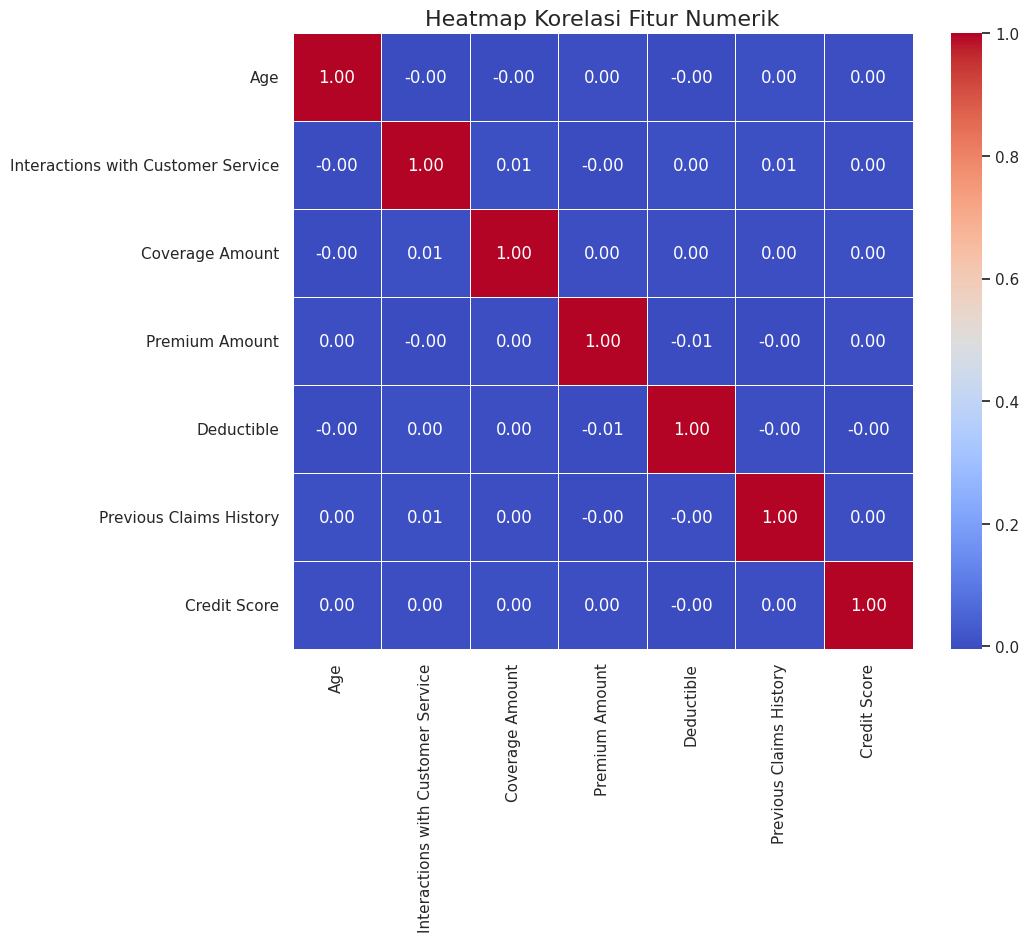

In [ ]:
if train_data is not None:
    # Pilih hanya kolom numerik (hati-hati, ini mungkin perlu disesuaikan)
    numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

    if not numerical_cols.empty:
        plt.figure(figsize=(10, 8))
        correlation_matrix = train_data[numerical_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Heatmap Korelasi Fitur Numerik', fontsize=16)
        plt.show()
    else:
        print("Tidak ada kolom numerik yang ditemukan untuk heatmap korelasi.")
else:
    print("DataFrame EDA tidak tersedia, plot tidak dapat dibuat.")

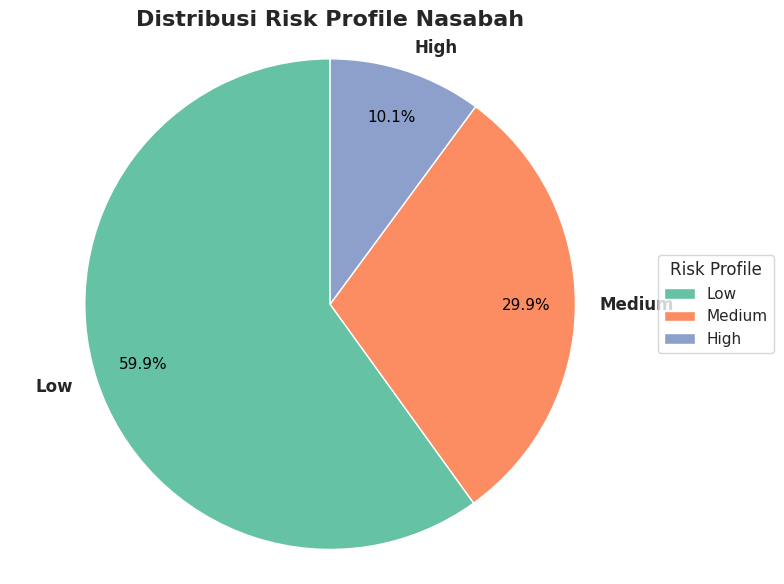

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung distribusi Risk Profile
risk_counts = train_data['Risk Profile'].value_counts()

# Warna dengan colormap
colors = sns.color_palette("Set2", n_colors=len(risk_counts))

# Buat pie chart
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 12},
    pctdistance=0.8
)

# Tambahkan garis penunjuk (jika ingin label di luar lingkaran)
for t in texts:
    t.set_fontweight('bold')
for a in autotexts:
    a.set_color('black')
    a.set_fontsize(11)

# Tambahkan judul dan legenda
plt.title('Distribusi Risk Profile Nasabah', fontsize=16, fontweight='bold')
plt.legend(wedges, risk_counts.index, title="Risk Profile", loc="center left", bbox_to_anchor=(1, 0.5))
plt.axis('equal')  # Biar pie chart-nya bulat
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import kurtosis, skew

# 1. Deteksi fitur numerik
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Hilangkan kolom target dan ID
exclude_cols = ['Customer ID', 'Risk Profile']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# 2. Deteksi fitur yang distribusinya mendekati uniform
uniform_features = []

print("Fitur dengan distribusi mendekati uniform (kurtosis rendah):")
for col in numerical_cols:
    k = kurtosis(train_data[col].dropna())
    if -1 < k < 1:  # rentang kurtosis mendekati distribusi uniform
        print(f"- {col} | kurtosis: {k:.2f}")
        uniform_features.append(col)

Fitur dengan distribusi mendekati uniform (kurtosis rendah):


In [ ]:
# import pandas as pd
# from category_encoders import TargetEncoder
# from sklearn.impute import SimpleImputer

# # Kolom yang akan diimputasi dan target
# cols_to_impute = ['Income Level', 'Education Level', 'Behavioral Data', 'Claim History']
# target_col = 'Risk Profile'  # Gantilah ini dengan nama kolom target kamu

# # Cek apakah kolom target tersedia
# assert target_col in train_data.columns, "Kolom target tidak ditemukan di DataFrame."

# # Inisialisasi Target Encoder
# te = TargetEncoder(cols=cols_to_impute)

# # Fit dan transform fitur berdasarkan target
# df_encoded = te.fit_transform(train_data[cols_to_impute], train_data[target_col])

# # Imputasi nilai yang hilang dengan nilai rata-rata (atau bisa most_frequent jika preferensi)
# imputer = SimpleImputer(strategy='mean')  # Bisa juga pakai 'median'
# df_imputed_values = imputer.fit_transform(df_encoded)

# # Simpan ke DataFrame baru
# df_imputed = pd.DataFrame(df_imputed_values, columns=cols_to_impute)

# # Timpa kembali ke data asli
# for col in cols_to_impute:
#     df[col] = df_imputed[col]


In [ ]:
train_data['Policy_Duration'] = (train_data['Policy Renewal Date'] - train_data['Policy Start Date']).dt.days
test_data['Policy_Duration'] = (test_data['Policy Renewal Date'] - test_data['Policy Start Date']).dt.days

train_data['Start_Year'] = train_data['Policy Start Date'].dt.year
test_data['Start_Year'] = test_data['Policy Start Date'].dt.year

train_data['Start_Month'] = train_data['Policy Start Date'].dt.month
test_data['Start_Month'] = test_data['Policy Start Date'].dt.month

In [ ]:
train_data['Premium_Coverage_Ratio'] = train_data['Premium Amount'] / (train_data['Coverage Amount'])
test_data['Premium_Coverage_Ratio'] = test_data['Premium Amount'] / (test_data['Coverage Amount'])

train_data['Deductible_Coverage_Ratio'] = train_data['Deductible'] / (train_data['Coverage Amount'] )
test_data['Deductible_Coverage_Ratio'] = test_data['Deductible'] / (test_data['Coverage Amount'] )

train_data['Premium_Age_Ratio'] = train_data['Premium Amount'] / (train_data['Age'])
test_data['Premium_Age_Ratio'] = test_data['Premium Amount'] / (test_data['Age'])

train_data['Age_Credit_Interaction'] = train_data['Age'] * train_data['Credit Score']
test_data['Age_Credit_Interaction'] = test_data['Age'] * test_data['Credit Score']

In [ ]:
date_columns = train_data.select_dtypes(include=['datetime64[ns]']).columns

train_data = train_data.drop(columns=date_columns)
test_data = test_data.drop(columns=date_columns)

In [ ]:
#Pilih hanya fitur numerik
numerical_features_to_normalize = train_data.select_dtypes(include=np.number).columns.tolist()

# Kolom yang tidak ingin dinormalisasi
cols_to_exclude = ['Risk Profile', 'Customer ID', 'Policy ID', 'Risk Profile_encoded']

# Buang semua kolom yang harus dikecualikan jika ada
numerical_features_to_normalize = [col for col in numerical_features_to_normalize if col not in cols_to_exclude]

print("Fitur numerik yang akan dinormalisasi:", numerical_features_to_normalize)

# Normalisasi
scaler = StandardScaler()
scaler.fit(train_data[numerical_features_to_normalize])

train_data[numerical_features_to_normalize] = scaler.transform(train_data[numerical_features_to_normalize])
test_data[numerical_features_to_normalize] = scaler.transform(test_data[numerical_features_to_normalize])

Fitur numerik yang akan dinormalisasi: ['Age', 'Interactions with Customer Service', 'Coverage Amount', 'Premium Amount', 'Deductible', 'Previous Claims History', 'Credit Score', 'Policy_Duration', 'Start_Year', 'Start_Month', 'Premium_Coverage_Ratio', 'Deductible_Coverage_Ratio', 'Premium_Age_Ratio', 'Age_Credit_Interaction']


In [ ]:
test_data[numerical_features_to_normalize].head()

,Age,Interactions with Customer Service,Coverage Amount,Premium Amount,Deductible,Previous Claims History,Credit Score,Policy_Duration,Start_Year,Start_Month,Premium_Coverage_Ratio,Deductible_Coverage_Ratio,Premium_Age_Ratio,Age_Credit_Interaction
20,0.700081,-1.121902,1.304171,0.814658,0.902708,0.709854,1.160401,-0.280213,0.915689,-1.606705,-0.287328,-0.289294,-0.031969,1.401073
34,-1.365432,-0.602146,0.020941,-1.449611,1.441840,0.709854,-0.281958,-0.498612,0.096462,0.132180,-0.410276,-0.118885,-0.883520,-1.148845
62,1.593276,-0.255641,1.264653,-0.463407,0.698022,0.002220,1.380849,-0.689423,0.096462,1.001622,-0.364204,-0.299161,-0.796619,2.527942
81,1.425802,1.130376,-0.955223,1.636304,0.372145,-1.413048,-0.949600,1.512957,-1.541993,1.581250,0.345081,0.047818,0.075645,0.265614
87,1.202504,1.303628,-0.093065,0.363975,0.608306,-0.705414,1.280072,1.278465,-1.541993,0.711808,-0.204919,-0.184611,-0.390142,2.020802


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Tandai data train dan test
train_data['is_train'] = 1
test_data['is_train'] = 0

# Gabungkan
combined = pd.concat([train_data, test_data])

# Mapping manual untuk risk_profile
risk_profile_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
combined['Risk Profile'] = combined['Risk Profile'].map(risk_profile_mapping)

# Deteksi semua kolom object KECUALI 'risk_profile'
object_cols = combined.select_dtypes(include='object').columns.drop('Risk Profile', errors='ignore')

# Encode kolom selain risk_profile
le = LabelEncoder()
for col in object_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

# Pisahkan kembali
train_data_encoded = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test_data_encoded = combined[combined['is_train'] == 0].drop(columns=['is_train'])

In [ ]:
train_data_encoded.head()

,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Driving Record,Life Events,Segmentation Group,Policy_Duration,Start_Year,Start_Month,Premium_Coverage_Ratio,Deductible_Coverage_Ratio,Premium_Age_Ratio,Age_Credit_Interaction
0,0,-0.304763,0,1,5,2,1,1,44996,1,...,2,4,2,-0.756093,0.915689,-1.606705,-0.157286,-0.163050,-0.270275,-0.577618
1,1,-1.477081,0,1,5,2,2,2,41816,4,...,0,1,0,0.112905,0.096462,-1.027077,1.373527,0.254512,3.427207,-1.148997
2,2,0.811731,1,0,4,1,1,2,12937,3,...,1,1,1,1.398010,-1.541993,1.001622,-0.081666,-0.199253,0.206177,-0.246164
3,3,0.644257,0,3,0,0,0,1,13509,0,...,2,3,3,0.340500,-0.722766,0.711808,-0.381282,-0.282926,-0.816194,0.905564
4,4,0.365133,1,1,6,2,3,1,4804,0,...,1,0,1,1.510658,-1.541993,1.291436,-0.285776,-0.292212,0.182867,-0.692411


In [ ]:
test_data_encoded.head()

,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Driving Record,Life Events,Segmentation Group,Policy_Duration,Start_Year,Start_Month,Premium_Coverage_Ratio,Deductible_Coverage_Ratio,Premium_Age_Ratio,Age_Credit_Interaction
20,20,0.700081,1,1,5,1,1,2,39139,2,...,0,1,2,-0.280213,0.915689,-1.606705,-0.287328,-0.289294,-0.031969,1.401073
34,34,-1.365432,1,0,2,3,1,0,37945,0,...,0,2,3,-0.498612,0.096462,0.132180,-0.410276,-0.118885,-0.883520,-1.148845
62,62,1.593276,0,1,2,0,3,1,7193,3,...,2,2,3,-0.689423,0.096462,1.001622,-0.364204,-0.299161,-0.796619,2.527942
81,81,1.425802,1,3,5,2,3,2,2635,2,...,2,0,4,1.512957,-1.541993,1.581250,0.345081,0.047818,0.075645,0.265614
87,87,1.202504,1,2,6,2,2,0,29298,0,...,2,4,1,1.278465,-1.541993,0.711808,-0.204919,-0.184611,-0.390142,2.020802



Korelasi fitur kategorikal terhadap Risk Profile:
Risk Profile                       1.000000
Segmentation Group                -0.004393
Customer Preferences               0.003230
Behavioral Data                   -0.003156
Geographic Information             0.003103
Occupation                        -0.002903
Driving Record                     0.002782
Claim History                     -0.002527
Location                           0.002259
Gender                            -0.001785
Policy Type                        0.001766
Customer ID                       -0.001708
Preferred Communication Channel    0.001630
Preferred Language                -0.001561
Income Level                      -0.001458
Life Events                       -0.001301
Insurance Products Owned          -0.001295
Education Level                   -0.001016
Purchase History                   0.000997
Marital Status                    -0.000760
Preferred Contact Time             0.000355
Name: Risk Profile, dtype

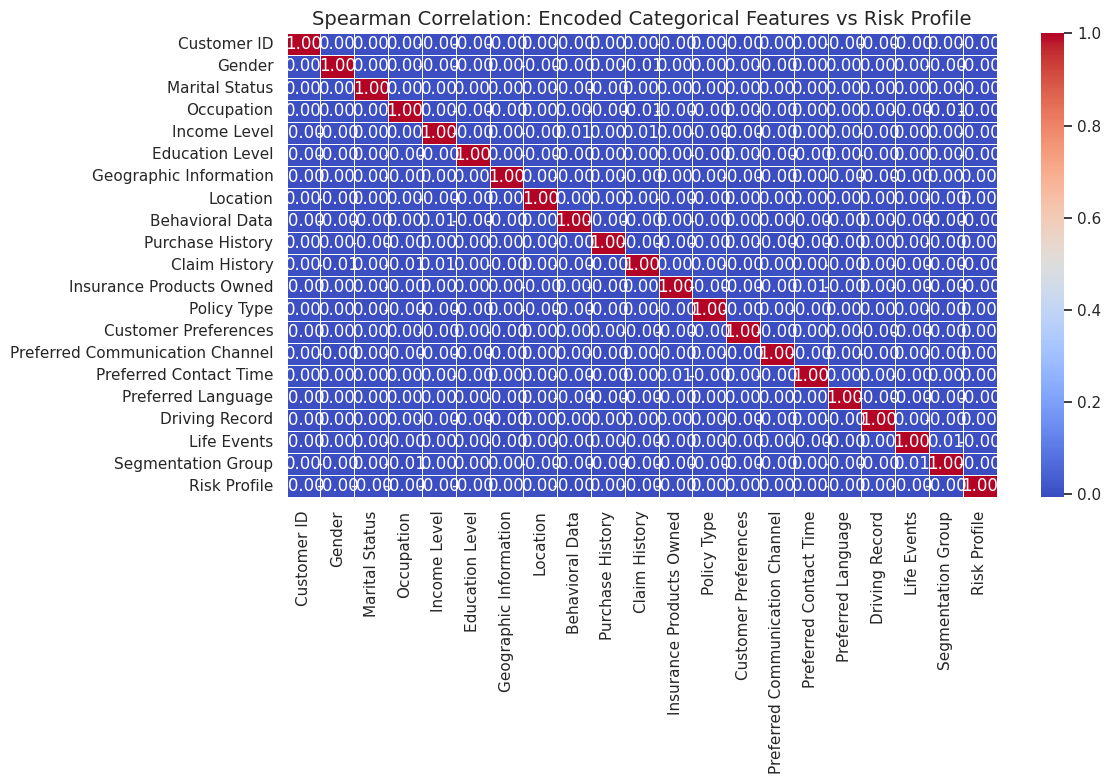

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil hanya kolom hasil encoding kategorikal + target
encoded_categorical_cols = object_cols.tolist()  # dari proses encoding
encoded_categorical_cols.append('Risk Profile')

# Filter dari train_data_encoded
cat_encoded_df = train_data_encoded[encoded_categorical_cols]

# Hitung korelasi Spearman (lebih cocok untuk data ordinal/kategorikal encoded)
corr_matrix = cat_encoded_df.corr(method='spearman')

# Tampilkan korelasi antara fitur dan target
print("\nKorelasi fitur kategorikal terhadap Risk Profile:")
print(corr_matrix['Risk Profile'].sort_values(key=abs, ascending=False))

# Visualisasi korelasi seluruh fitur kategorikal
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Spearman Correlation: Encoded Categorical Features vs Risk Profile", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
train_data_encoded = train_data_encoded.drop('Customer ID', axis=1)
test_data_encoded = test_data_encoded.drop('Customer ID', axis=1)

train_data_encoded.head()

,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,Purchase History,...,Driving Record,Life Events,Segmentation Group,Policy_Duration,Start_Year,Start_Month,Premium_Coverage_Ratio,Deductible_Coverage_Ratio,Premium_Age_Ratio,Age_Credit_Interaction
0,-0.304763,0,1,5,2,1,1,44996,1,0,...,2,4,2,-0.756093,0.915689,-1.606705,-0.157286,-0.163050,-0.270275,-0.577618
1,-1.477081,0,1,5,2,2,2,41816,4,2,...,0,1,0,0.112905,0.096462,-1.027077,1.373527,0.254512,3.427207,-1.148997
2,0.811731,1,0,4,1,1,2,12937,3,1,...,1,1,1,1.398010,-1.541993,1.001622,-0.081666,-0.199253,0.206177,-0.246164
3,0.644257,0,3,0,0,0,1,13509,0,2,...,2,3,3,0.340500,-0.722766,0.711808,-0.381282,-0.282926,-0.816194,0.905564
4,0.365133,1,1,6,2,3,1,4804,0,1,...,1,0,1,1.510658,-1.541993,1.291436,-0.285776,-0.292212,0.182867,-0.692411


In [ ]:
test_data_encoded.head()

,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,Purchase History,...,Driving Record,Life Events,Segmentation Group,Policy_Duration,Start_Year,Start_Month,Premium_Coverage_Ratio,Deductible_Coverage_Ratio,Premium_Age_Ratio,Age_Credit_Interaction
20,0.700081,1,1,5,1,1,2,39139,2,0,...,0,1,2,-0.280213,0.915689,-1.606705,-0.287328,-0.289294,-0.031969,1.401073
34,-1.365432,1,0,2,3,1,0,37945,0,1,...,0,2,3,-0.498612,0.096462,0.132180,-0.410276,-0.118885,-0.883520,-1.148845
62,1.593276,0,1,2,0,3,1,7193,3,1,...,2,2,3,-0.689423,0.096462,1.001622,-0.364204,-0.299161,-0.796619,2.527942
81,1.425802,1,3,5,2,3,2,2635,2,1,...,2,0,4,1.512957,-1.541993,1.581250,0.345081,0.047818,0.075645,0.265614
87,1.202504,1,2,6,2,2,0,29298,0,2,...,2,4,1,1.278465,-1.541993,0.711808,-0.204919,-0.184611,-0.390142,2.020802


In [ ]:
import numpy as np
from scipy.stats import skew

# Gunakan hasil encoding: train_data_encoded
# 1. Pilih kolom numerik
numerical_cols = train_data_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Kecualikan kolom target 'Risk Profile' jika masih ada
if 'Risk Profile' in numerical_cols:
    numerical_cols.remove('Risk Profile')

# 3. Hitung skewness
skewed = train_data_encoded[numerical_cols].apply(lambda x: skew(x.dropna()))
skewed_cols = skewed[skewed > 1.0].index.tolist()  # Ambil yang skewed

# 4. Cek apakah ada nilai nol atau negatif, lalu sesuaikan
for col in skewed_cols:
    min_val = train_data_encoded[col].min()
    if min_val <= 0:
        train_data_encoded[col] = train_data_encoded[col] + (1 - min_val)  # Supaya minimal jadi 1

# 5. Lakukan log transform
train_data_encoded[skewed_cols] = np.log(train_data_encoded[skewed_cols])

# 6. Tampilkan kolom yang ditransformasi
print("Log transform dilakukan pada kolom:")
print(skewed_cols)


Log transform dilakukan pada kolom:
['Premium_Coverage_Ratio', 'Deductible_Coverage_Ratio', 'Premium_Age_Ratio']


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# =======================
# 1. Pisahkan fitur dan target
# =======================
X = train_data_encoded.drop(columns='Risk Profile')
y = train_data_encoded['Risk Profile']

print("Distribusi awal kelas:")
print(Counter(y))

# =======================
# 2. Split data sebelum SMOTE (stratify by y)
# =======================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nDistribusi y_train sebelum SMOTE:")
print(Counter(y_train))

# =======================
# 3. Terapkan BorderlineSMOTE hanya ke training set
# =======================
smote = BorderlineSMOTE(random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nDistribusi y_train setelah BorderlineSMOTE:")
print(Counter(y_train_resampled))

# =======================
# 4. (Opsional) Scaling untuk model sensitif (LogReg, SVM, ANN)
# =======================
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_resampled)
# X_val_scaled = scaler.transform(X_val)

# # Gunakan X_train_scaled dan X_val_scaled jika pakai model sensitif terhadap skala data

# =======================
# 5. Ukuran set
# =======================
print("\nUkuran X_train (setelah resample):", X_train_resampled.shape)
print("Ukuran X_val:", X_val.shape)
print("Ukuran y_train:", y_train_resampled.shape)
print("Ukuran y_val:", y_val.shape)

Distribusi awal kelas:
Counter({0.0: 85428, 1.0: 42678, 2.0: 14394})

Distribusi y_train sebelum SMOTE:
Counter({0.0: 68343, 1.0: 34142, 2.0: 11515})

Distribusi y_train setelah BorderlineSMOTE:
Counter({0.0: 68343, 1.0: 68343, 2.0: 68343})

Ukuran X_train (setelah resample): (205029, 33)
Ukuran X_val: (28500, 33)
Ukuran y_train: (205029,)
Ukuran y_val: (28500,)


In [ ]:
# Inisialisasi model Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, # Jumlah pohon dalam forest
                                  random_state=42, # Untuk reproducibility
                                  class_weight='balanced' # Menangani imbalansi kelas jika ada
                                 )

# Latih model menggunakan data training
rf_model.fit(X_train, y_train)

# Prediksi pada data validasi
y_pred = rf_model.predict(X_val)

# Evaluasi model
print("Classification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75     17085
         1.0       0.37      0.00      0.00      8536
         2.0       0.00      0.00      0.00      2879

    accuracy                           0.60     28500
   macro avg       0.32      0.33      0.25     28500
weighted avg       0.47      0.60      0.45     28500


Confusion Matrix:
[[17074    11     0]
 [ 8529     7     0]
 [ 2878     1     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# # prompt: lakukan prediksi terhadap test_data dan export dalam bentuk csv

# import pandas as pd
# # Siapkan data test
# # Pastikan kolom-kolom di test_data_encoded sama dengan X_train
# # Jika ada kolom yang hilang di test (karena missing values awalnya atau proses sebelumnya),
# # tambahkan kolom tersebut dengan nilai default (misalnya 0 atau rata-rata kolom di train)
# # Atau pastikan preprocessing diaplikasikan secara konsisten

# # Pastikan urutan kolom sama
# test_data_encoded = test_data_encoded[X_train.columns]

# # Lakukan prediksi pada test data
# test_predictions_encoded = rf_model.predict(test_data_encoded)

# # Dekode hasil prediksi kembali ke label asli (Low, Medium, High)
# # Gunakan mapping yang sama seperti saat encode
# reverse_risk_profile_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
# test_predictions = pd.Series(test_predictions_encoded).map(reverse_risk_profile_mapping)

# # Buat DataFrame hasil prediksi
# # Ambil Customer ID dari data test awal sebelum encoding dan dropping
# # Perlu dicari cara mendapatkan Customer ID yang sesuai dengan test_data_encoded
# # Jika Customer ID di drop setelah split, maka perlu disimpan dulu ID dari test_data asli
# # Asumsi Customer ID dari test_data asli masih tersedia dan urutannya cocok
# test_customer_ids = df[df['Risk Profile'].isna()]['Customer ID'].reset_index(drop=True)

# submission_df = pd.DataFrame({
#     'Customer ID': test_customer_ids,
#     'Risk Profile': test_predictions
# })

# # Simpan hasil prediksi ke CSV
# output_filename = 'submission.csv'
# submission_df.to_csv(output_filename, index=False)

# print(f"Prediksi berhasil disimpan ke {output_filename}")
# print("\nContoh hasil prediksi:")
# print(submission_df.head())

In [ ]:
# test = pd.read_csv('submission.csv')
# test.head(30)

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# ============================================
# 1. Inisialisasi Model Random Forest
# ============================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# ============================================
# 2. Setup Stratified K-Fold Cross Validation
# ============================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================
# 3. Evaluasi Akurasi di Setiap Fold
# ============================================
accuracy_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
print("🔹 Akurasi per Fold:", accuracy_scores)
print("🔹 Rata-rata Akurasi: {:.4f}".format(np.mean(accuracy_scores)))

# ============================================
# 4. Evaluasi F1-Score (Weighted) per Fold
# ============================================
f1_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='f1_weighted')
print("\n🔹 F1-Score per Fold:", f1_scores)
print("🔹 Rata-rata F1-Score: {:.4f}".format(np.mean(f1_scores)))

# ============================================
# 5. Cross-Val Predict → Global Evaluasi
# ============================================
y_pred_cv = cross_val_predict(rf_model, X, y, cv=cv)

print("\n📋 Classification Report (Cross-Val):")
print(classification_report(y, y_pred_cv))

print("📊 Confusion Matrix (Cross-Val):")
print(confusion_matrix(y, y_pred_cv))


🔹 Akurasi per Fold: [0.59936842 0.59912281 0.59926316 0.59922807 0.59936842]
🔹 Rata-rata Akurasi: 0.5993

🔹 F1-Score per Fold: [0.44979931 0.44971313 0.44984243 0.44960005 0.44983637]
🔹 Rata-rata F1-Score: 0.4498

📋 Classification Report (Cross-Val):
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75     85428
         1.0       0.29      0.00      0.00     42678
         2.0       0.00      0.00      0.00     14394

    accuracy                           0.60    142500
   macro avg       0.30      0.33      0.25    142500
weighted avg       0.45      0.60      0.45    142500

📊 Confusion Matrix (Cross-Val):
[[85361    67     0]
 [42643    35     0]
 [14376    18     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi model Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    random_state=42,       # Untuk reproducibility
    class_weight='balanced'  # Menangani ketidakseimbangan kelas jika ada
)

# Latih model menggunakan data training
dt_model.fit(X_train, y_train)

# Prediksi pada data validasi
y_pred = dt_model.predict(X_val)

# Evaluasi model
print("Classification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60     17085
         1.0       0.30      0.29      0.29      8536
         2.0       0.11      0.11      0.11      2879

    accuracy                           0.46     28500
   macro avg       0.33      0.33      0.33     28500
weighted avg       0.46      0.46      0.46     28500


Confusion Matrix:
[[10242  4985  1858]
 [ 5142  2476   918]
 [ 1689   864   326]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =======================
# 1. Inisialisasi model
# =======================
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

# =======================
# 2. Setup Cross Validation
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =======================
# 3. Evaluasi Akurasi
# =======================
accuracy_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='accuracy')
print("🔹 Akurasi per Fold:", accuracy_scores)
print("🔹 Rata-rata Akurasi: {:.4f}".format(np.mean(accuracy_scores)))

# =======================
# 4. Evaluasi F1-score
# =======================
f1_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='f1_weighted')
print("\n🔹 F1-score per Fold:", f1_scores)
print("🔹 Rata-rata F1-score: {:.4f}".format(np.mean(f1_scores)))

# =======================
# 5. Prediksi Global CV
# =======================
y_pred_cv = cross_val_predict(dt_model, X, y, cv=cv)

print("\n📋 Classification Report (Cross-Val):")
print(classification_report(y, y_pred_cv))

print("📊 Confusion Matrix (Cross-Val):")
print(confusion_matrix(y, y_pred_cv))


🔹 Akurasi per Fold: [0.46014035 0.45491228 0.45936842 0.45849123 0.45947368]
🔹 Rata-rata Akurasi: 0.4585

🔹 F1-score per Fold: [0.46004748 0.45625395 0.4605054  0.45926913 0.46015216]
🔹 Rata-rata F1-score: 0.4592

📋 Classification Report (Cross-Val):
              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60     85428
         1.0       0.30      0.30      0.30     42678
         2.0       0.10      0.10      0.10     14394

    accuracy                           0.46    142500
   macro avg       0.33      0.33      0.33    142500
weighted avg       0.46      0.46      0.46    142500

📊 Confusion Matrix (Cross-Val):
[[51057 25485  8886]
 [25423 12778  4477]
 [ 8525  4371  1498]]


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi model LGBM
lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # menangani ketidakseimbangan kelas
)

# Latih model
lgbm_model.fit(X_train, y_train)

# Prediksi
y_pred_lgbm = lgbm_model.predict(X_val)

# Evaluasi
print("LGBM Classification Report:")
print(classification_report(y_val, y_pred_lgbm))

print("\nLGBM Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_lgbm))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008645 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 114000, number of used features: 33
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBM Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.38      0.46     17085
         1.0       0.30      0.35      0.32      8536
         2.0       0.10      0.28      0.15      2879

    accuracy                           0.36     28500
   macro avg       0.33      0.33      0.31     28500
weighted avg       0.46      0.36      0.39     28

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =======================
# 1. Inisialisasi Model LGBM
# =======================
lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# =======================
# 2. Stratified K-Fold Setup
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =======================
# 3. Evaluasi Akurasi Tiap Fold
# =======================
accuracy_scores = cross_val_score(lgbm_model, X, y, cv=cv, scoring='accuracy')
print("🔹 Akurasi per Fold:", accuracy_scores)
print("🔹 Rata-rata Akurasi: {:.4f}".format(np.mean(accuracy_scores)))

# =======================
# 4. Evaluasi F1-Score Tiap Fold
# =======================
f1_scores = cross_val_score(lgbm_model, X, y, cv=cv, scoring='f1_weighted')
print("\n🔹 F1-score per Fold:", f1_scores)
print("🔹 Rata-rata F1-score: {:.4f}".format(np.mean(f1_scores)))

# =======================
# 5. Evaluasi Global (Cross-Val Predict)
# =======================
y_pred_cv = cross_val_predict(lgbm_model, X, y, cv=cv)

print("\n📋 Classification Report (Cross-Val):")
print(classification_report(y, y_pred_cv))

print("📊 Confusion Matrix (Cross-Val):")
print(confusion_matrix(y, y_pred_cv))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 114000, number of used features: 33
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 114000

In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi model Logistic Regression
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Latih model
logreg_model.fit(X_train, y_train)

# Prediksi
y_pred_logreg = logreg_model.predict(X_val)

# Evaluasi
print("Logistic Regression Classification Report:")
print(classification_report(y_val, y_pred_logreg))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_logreg))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.32      0.42     17085
         1.0       0.31      0.31      0.31      8536
         2.0       0.10      0.37      0.16      2879

    accuracy                           0.32     28500
   macro avg       0.33      0.33      0.30     28500
weighted avg       0.46      0.32      0.36     28500


Logistic Regression Confusion Matrix:
[[5529 5139 6417]
 [2774 2641 3121]
 [ 936  879 1064]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =======================
# 1. Inisialisasi Model
# =======================
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# =======================
# 2. Stratified K-Fold Setup
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =======================
# 3. Evaluasi Akurasi
# =======================
accuracy_scores = cross_val_score(logreg_model, X, y, cv=cv, scoring='accuracy')
print("🔹 Akurasi per Fold:", accuracy_scores)
print("🔹 Rata-rata Akurasi: {:.4f}".format(np.mean(accuracy_scores)))

# =======================
# 4. Evaluasi F1-score
# =======================
f1_scores = cross_val_score(logreg_model, X, y, cv=cv, scoring='f1_weighted')
print("\n🔹 F1-score per Fold:", f1_scores)
print("🔹 Rata-rata F1-score: {:.4f}".format(np.mean(f1_scores)))

# =======================
# 5. Prediksi Global Cross-Val
# =======================
y_pred_cv = cross_val_predict(logreg_model, X, y, cv=cv)

print("\n📋 Classification Report (Cross-Val):")
print(classification_report(y, y_pred_cv))

print("📊 Confusion Matrix (Cross-Val):")
print(confusion_matrix(y, y_pred_cv))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

🔹 Akurasi per Fold: [0.30449123 0.31740351 0.32522807 0.32087719 0.30238596]
🔹 Rata-rata Akurasi: 0.3141


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


🔹 F1-score per Fold: [0.33725705 0.35261705 0.36237518 0.35429636 0.33246227]
🔹 Rata-rata F1-score: 0.3478


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


📋 Classification Report (Cross-Val):
              precision    recall  f1-score   support

         0.0       0.60      0.30      0.40     85428
         1.0       0.30      0.33      0.31     42678
         2.0       0.10      0.38      0.16     14394

    accuracy                           0.31    142500
   macro avg       0.33      0.33      0.29    142500
weighted avg       0.46      0.31      0.35    142500

📊 Confusion Matrix (Cross-Val):
[[25414 27634 32380]
 [12658 13937 16083]
 [ 4339  4650  5405]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,  # Nonaktifkan warning untuk versi baru
    eval_metric='mlogloss',   # Evaluasi multikelas atau binary
    scale_pos_weight=1        # Bisa diubah untuk dataset tidak seimbang
)

# Latih model
xgb_model.fit(X_train, y_train)

# Prediksi
y_pred_xgb = xgb_model.predict(X_val)

# Evaluasi
print("XGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb))

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:34:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75     17085
         1.0       0.30      0.00      0.00      8536
         2.0       0.00      0.00      0.00      2879

    accuracy                           0.60     28500
   macro avg       0.30      0.33      0.25     28500
weighted avg       0.45      0.60      0.45     28500


XGBoost Confusion Matrix:
[[17078     7     0]
 [ 8533     3     0]
 [ 2879     0     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =======================
# 1. Inisialisasi Model
# =======================
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    scale_pos_weight=1
)

# =======================
# 2. Stratified K-Fold Setup
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =======================
# 3. Evaluasi Akurasi per Fold
# =======================
accuracy_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')
print("🔹 Akurasi per Fold:", accuracy_scores)
print("🔹 Rata-rata Akurasi: {:.4f}".format(np.mean(accuracy_scores)))

# =======================
# 4. Evaluasi F1-score per Fold
# =======================
f1_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1_weighted')
print("\n🔹 F1-score per Fold:", f1_scores)
print("🔹 Rata-rata F1-score: {:.4f}".format(np.mean(f1_scores)))

# =======================
# 5. Prediksi Global Cross-Val
# =======================
y_pred_cv = cross_val_predict(xgb_model, X, y, cv=cv)

print("\n📋 Classification Report (Cross-Val):")
print(classification_report(y, y_pred_cv))

print("📊 Confusion Matrix (Cross-Val):")
print(confusion_matrix(y, y_pred_cv))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:34:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:34:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:34:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:34:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning

🔹 Akurasi per Fold: [0.59936842 0.59954386 0.59954386 0.59950877 0.59957895]
🔹 Rata-rata Akurasi: 0.5995


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:34:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning


🔹 F1-score per Fold: [0.44947253 0.44961836 0.44981849 0.44957561 0.44980874]
🔹 Rata-rata F1-score: 0.4497


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:35:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning


📋 Classification Report (Cross-Val):
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75     85428
         1.0       0.44      0.00      0.00     42678
         2.0       0.00      0.00      0.00     14394

    accuracy                           0.60    142500
   macro avg       0.35      0.33      0.25    142500
weighted avg       0.49      0.60      0.45    142500

📊 Confusion Matrix (Cross-Val):
[[85410    18     0]
 [42658    20     0]
 [14387     7     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# =======================================
# 0. Import Library
# =======================================
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =======================================
# 1. Split Data (jika belum)
# =======================================
# Pastikan X dan y sudah disiapkan sebelumnya
# Contoh: X = train_data_encoded.drop(columns='Risk Profile')
#         y = train_data_encoded['Risk Profile']

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =======================================
# 2. Definisikan Fungsi Tuning Optuna
# =======================================
def objective(trial):
    model_name = trial.suggest_categorical('model', ['xgb', 'rf', 'logreg', 'lgbm'])

    if model_name == 'xgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'mlogloss',
            'scale_pos_weight': 1,
        }
        model = XGBClassifier(**params)

    elif model_name == 'rf':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
            'class_weight': 'balanced',
            'random_state': 42
        }
        model = RandomForestClassifier(**params)

    elif model_name == 'logreg':
        params = {
            'C': trial.suggest_float('C', 0.001, 10.0, log=True),
            'penalty': 'l2',
            'solver': 'lbfgs',
            'class_weight': 'balanced',
            'max_iter': 1000,
            'random_state': 42
        }
        model = LogisticRegression(**params)

    elif model_name == 'lgbm':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'class_weight': 'balanced',
            'random_state': 42
        }
        model = LGBMClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, scoring='f1_weighted', cv=cv, n_jobs=-1)
    return np.mean(scores)

# =======================================
# 3. Jalankan Optuna Tuning
# =======================================
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=900)  # max 15 menit atau 50 percobaan

# =======================================
# 4. Lihat Hasil Terbaik
# =======================================
print("✅ Best Model:", study.best_params['model'])
print("🏆 Best F1-score:", study.best_value)
print("🔧 Best Parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# =======================================
# 5. Training Ulang Model Terbaik
# =======================================
best_params = study.best_params.copy()
model_type = best_params.pop('model')

# Siapkan model final
if model_type == 'xgb':
    best_params.update({'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'mlogloss'})
    final_model = XGBClassifier(**best_params)
elif model_type == 'rf':
    best_params.update({'random_state': 42, 'class_weight': 'balanced'})
    final_model = RandomForestClassifier(**best_params)
elif model_type == 'logreg':
    best_params.update({'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced', 'solver': 'lbfgs'})
    final_model = LogisticRegression(**best_params)
elif model_type == 'lgbm':
    best_params.update({'random_state': 42, 'class_weight': 'balanced'})
    final_model = LGBMClassifier(**best_params)

# Train dan evaluasi
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_val)

print("\n📋 Final Classification Report (Validation Set):")
print(classification_report(y_val, y_pred))

print("📊 Final Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))


[I 2025-05-25 16:23:00,224] A new study created in memory with name: no-name-965bef85-4395-4da4-96d5-c6738b440a96
[I 2025-05-25 16:23:37,725] Trial 0 finished with value: 0.44939074733411405 and parameters: {'model': 'xgb', 'n_estimators': 269, 'max_depth': 4, 'learning_rate': 0.014711162050792618, 'subsample': 0.6007113729728488, 'colsample_bytree': 0.8248569976119977}. Best is trial 0 with value: 0.44939074733411405.
[I 2025-05-25 16:27:32,158] Trial 1 finished with value: 0.46758189349928675 and parameters: {'model': 'rf', 'n_estimators': 214, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.46758189349928675.
/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[I 2025-05-25 16:28:09,811] Trial 2 finished with value: 0.435009577751089 and parame

✅ Best Model: xgb
🏆 Best F1-score: 0.47951821169649234
🔧 Best Parameters:
  model: xgb
  n_estimators: 265
  max_depth: 8
  learning_rate: 0.283325802349433
  subsample: 0.5995116725922524
  colsample_bytree: 0.6189227932238432


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:41:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📋 Final Classification Report (Validation Set):
              precision    recall  f1-score   support

         0.0       0.60      0.87      0.71     17085
         1.0       0.30      0.12      0.17      8536
         2.0       0.11      0.01      0.01      2879

    accuracy                           0.56     28500
   macro avg       0.34      0.33      0.30     28500
weighted avg       0.46      0.56      0.48     28500

📊 Final Confusion Matrix:
[[14836  2171    78]
 [ 7438  1059    39]
 [ 2518   346    15]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Buat dictionary untuk menyimpan model final berdasarkan best params
def get_model(name, params):
    if name == 'xgb':
        params.update({'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'mlogloss'})
        return XGBClassifier(**params)
    elif name == 'rf':
        params.update({'random_state': 42, 'class_weight': 'balanced'})
        return RandomForestClassifier(**params)
    elif name == 'logreg':
        params.update({'max_iter': 1000, 'random_state': 42, 'class_weight': 'balanced', 'solver': 'lbfgs'})
        return LogisticRegression(**params)
    elif name == 'lgbm':
        params.update({'random_state': 42, 'class_weight': 'balanced'})
        return LGBMClassifier(**params)

# Jalankan semua model untuk evaluasi (dengan best params jika ada)
model_list = ['xgb', 'rf', 'logreg', 'lgbm']

for model_name in model_list:
    # Ambil parameter dari Optuna jika model tersebut pernah dituning
    tuned_params = {k: v for k, v in study.best_params.items() if k != 'model'} if study.best_params['model'] == model_name else {}

    model = get_model(model_name, tuned_params.copy())

    # Fit dan prediksi
    model.fit(X_train, y_train)
    y_pred_model = model.predict(X_val)

    print(f"\n===============================")
    print(f"🔍 Classification Report for: {model_name.upper()}")
    print(f"===============================")
    print(classification_report(y_val, y_pred_model))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_model))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:42:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔍 Classification Report for: XGB
              precision    recall  f1-score   support

         0.0       0.60      0.87      0.71     17085
         1.0       0.30      0.12      0.17      8536
         2.0       0.11      0.01      0.01      2879

    accuracy                           0.56     28500
   macro avg       0.34      0.33      0.30     28500
weighted avg       0.46      0.56      0.48     28500

Confusion Matrix:
[[14836  2171    78]
 [ 7438  1059    39]
 [ 2518   346    15]]

🔍 Classification Report for: RF
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75     17085
         1.0       0.37      0.00      0.00      8536
         2.0       0.00      0.00      0.00      2879

    accuracy                           0.60     28500
   macro avg       0.32      0.33      0.25     28500
weighted avg       0.47      0.60      0.45     28500

Confusion Matrix:
[[17074    11     0]
 [ 8529     7     0]
 [ 2878     1     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/l


🔍 Classification Report for: LOGREG
              precision    recall  f1-score   support

         0.0       0.60      0.32      0.42     17085
         1.0       0.31      0.31      0.31      8536
         2.0       0.10      0.37      0.16      2879

    accuracy                           0.32     28500
   macro avg       0.33      0.33      0.30     28500
weighted avg       0.46      0.32      0.36     28500

Confusion Matrix:
[[5529 5139 6417]
 [2774 2641 3121]
 [ 936  879 1064]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 114000, number of used features: 33
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Sta

In [ ]:
# prompt: ubah ke file berbentuk pkl

import pickle

# Simpan model terbaik ke file .pkl
# Tentukan nama file untuk model
filename = f'{model_type}_final_model.pkl'

# Simpan model menggunakan pickle
with open(filename, 'wb') as file:
    pickle.dump(final_model, file)

print(f"Model terbaik ({model_type.upper()}) telah disimpan ke {filename}")

# Anda bisa memuat kembali model nanti dengan:
# with open(filename, 'rb') as file:
#     loaded_model = pickle.load(file)

Model terbaik (XGB) telah disimpan ke xgb_final_model.pkl


In [ ]:
# prompt: ubah ke file berbentuk pkl untuk model random forest

import pickle

# Simpan model Random Forest ke file .pkl
# Temukan model Random Forest yang dilatih sebelumnya.
# Jika Anda sudah melakukan tuning Optuna, gunakan model terbaik (final_model) jika itu RF.
# Jika belum atau ingin menyimpan model RF sebelum tuning, gunakan rf_model yang dilatih pada X_train/y_train.

# Asumsikan 'rf_model' adalah model Random ForestClassifier yang sudah dilatih
# Jika Optuna memilih RF sebagai model terbaik, Anda bisa menggunakan 'final_model'
# Tentukan model yang ingin Anda simpan
model_to_save = rf_model # Ganti dengan final_model jika RF adalah model terbaik dari Optuna

# Tentukan nama file untuk model
filename = 'random_forest_model.pkl'

# Simpan model menggunakan pickle
with open(filename, 'wb') as file:
    pickle.dump(model_to_save, file)

print(f"Model Random Forest telah disimpan ke {filename}")

# Anda bisa memuat kembali model nanti dengan:
# with open(filename, 'rb') as file:
#     loaded_rf_model = pickle.load(file)

Model Random Forest telah disimpan ke random_forest_model.pkl


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Bangun model feedforward neural network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(set(y_train)), activation='softmax')  # output layer untuk klasifikasi multikelas
])
# Kompilasi model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # cocok untuk label integer
    metrics=['accuracy']
)

# Callback untuk early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
# Prediksi
y_pred_dl = model.predict(X_val_scaled)
y_pred_dl_labels = y_pred_dl.argmax(axis=1)

# Evaluasi
print("Deep Learning Classification Report:")
print(classification_report(y_val, y_pred_dl_labels))

print("\nDeep Learning Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_dl_labels))

In [ ]:
# import torch
# from pytorch_tabnet.tab_model import TabNetClassifier
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import classification_report, confusion_matrix
# import numpy as np

# # Pastikan label berupa angka
# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)
# y_val_enc = le.transform(y_val)

# # Konversi ke numpy array
# X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
# X_val_np = X_val.values if hasattr(X_val, 'values') else X_val

# # Inisialisasi dan training TabNet
# tabnet_model = TabNetClassifier(
#     verbose=1,
#     seed=42,
#     device_name='cuda' if torch.cuda.is_available() else 'cpu'
# )

# tabnet_model.fit(
#     X_train=X_train_np, y_train=y_train_enc,
#     eval_set=[(X_val_np, y_val_enc)],
#     eval_name=["val"],
#     eval_metric=["accuracy"],
#     max_epochs=100,
#     patience=10,
#     batch_size=1024
# )

# # Prediksi dan evaluasi
# y_pred_tabnet = tabnet_model.predict(X_val_np)
# print("TabNet Classification Report:")
# print(classification_report(y_val_enc, y_pred_tabnet, target_names=le.classes_))

# print("TabNet Confusion Matrix:")
# print(confusion_matrix(y_val_enc, y_pred_tabnet))


In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# from sklearn.neighbors import KNeighborsClassifier

# def evaluate_knn(X_train, y_train, X_val, y_val, k=5):
#     print(f"\n===== K-Nearest Neighbors (k={k}) =====")

#     # Inisialisasi dan training
#     model = KNeighborsClassifier(n_neighbors=k)
#     model.fit(X_train, y_train)

#     # Prediksi
#     y_pred = model.predict(X_val)

#     # Evaluasi
#     acc = accuracy_score(y_val, y_pred)
#     print(f"Akurasi: {acc:.4f}")

#     print("\nClassification Report:")
#     print(classification_report(y_val, y_pred))

#     print("Confusion Matrix:")
#     print(confusion_matrix(y_val, y_pred))

#     return model, acc

# # Evaluasi untuk beberapa nilai k
# results = {}
# for k in [3, 5, 7, 9]:
#     model, acc = evaluate_knn(X_train_scaled, y_train, X_val_scaled, y_val, k)
#     results[k] = acc

# # Ringkasan skor akurasi
# print("\n===== Ringkasan Akurasi KNN =====")
# for k, acc in results.items():
#     print(f"k = {k} → Akurasi = {acc:.4f}")
